In [ ]:
import pandas as pd

import numpy as np
from scipy import stats
import sys
np.set_printoptions(threshold=sys.maxsize) # prevents truncuation

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw

from sklearn import linear_model
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
plt.rcParams['figure.dpi'] = 200
plt.rcParams["figure.figsize"] = (8, 5)

In [ ]:
smiles = pd.read_csv('initial_dataset.csv')

In [ ]:
df = pd.read_csv('Compiled_experimental_data_division_April_2025.csv')

# Parameters

In [ ]:
# initializes array of fp arrays
morgan_fps = []

r = 2 # radius
bits = 256 # nBits

# Creating FPs of Compounds

In [ ]:
# note: proprietary/confidential compound structures are assigned generic alias names below.

# compound 1
compound = Chem.MolFromSmiles(smiles.at[14,'smiles'])
info = {}
fp = AllChem.GetMorganFingerprintAsBitVect(compound, radius=r, nBits=bits, bitInfo=info)
fpvector = np.array(fp)

morgan_fps.append(fpvector)

# compound 2
compound = Chem.MolFromSmiles(smiles.at[20,'smiles'])
info = {}
fp = AllChem.GetMorganFingerprintAsBitVect(compound, radius=r, nBits=bits, bitInfo=info)
fpvector = np.array(fp)

morgan_fps.append(fpvector)

# compound 3
compound = Chem.MolFromSmiles(smiles.at[12,'smiles'])
info = {}
fp = AllChem.GetMorganFingerprintAsBitVect(compound, radius=r, nBits=bits, bitInfo=info)
fpvector = np.array(fp)

morgan_fps.append(fpvector)

# compound 4
compound = Chem.MolFromSmiles(smiles.at[25,'smiles'])
info = {}
fp = AllChem.GetMorganFingerprintAsBitVect(compound, radius=r, nBits=bits, bitInfo=info)
fpvector = np.array(fp)

morgan_fps.append(fpvector)

# compound 5
compound = Chem.MolFromSmiles(smiles.at[9,'smiles'])
info = {}
fp = AllChem.GetMorganFingerprintAsBitVect(compound, radius=r, nBits=bits, bitInfo=info)
fpvector = np.array(fp)

morgan_fps.append(fpvector)

# compound 6
compound = Chem.MolFromSmiles(smiles.at[23,'smiles'])
info = {}
fp = AllChem.GetMorganFingerprintAsBitVect(compound, radius=r, nBits=bits, bitInfo=info)
fpvector = np.array(fp)

morgan_fps.append(fpvector)

# compound 7
compound = Chem.MolFromSmiles(smiles.at[7,'smiles'])
info = {}
fp = AllChem.GetMorganFingerprintAsBitVect(compound, radius=r, nBits=bits, bitInfo=info)
fpvector = np.array(fp)

morgan_fps.append(fpvector)

# compound 8
compound = Chem.MolFromSmiles(smiles.at[24,'smiles'])
info = {}
fp = AllChem.GetMorganFingerprintAsBitVect(compound, radius=r, nBits=bits, bitInfo=info)
fpvector = np.array(fp)

morgan_fps.append(fpvector)

In [ ]:
np.stack(morgan_fps).shape

(8, 256)

# Test-Train Split of Data

In [ ]:
# array of ifn_b values from initial_dataset dataframe
ifn_b = df["IFN-b⬆"].to_numpy()

# imports train_test_split from sklearn
from sklearn.model_selection import train_test_split

# fps_train -> fingerprints model is trained on
# fps_test -> fingerprints model tests
# ifnb_train -> ifn_b values model is trained on
# ifnb_test -> ifn_b value model tests
# test_size=0.2 -> 80% training, 20% test split
# random_state=1 -> for reproducibility
i_fps_train, i_fps_test, ifnb_train, ifnb_test = train_test_split(
    morgan_fps, ifn_b, test_size=0.25, random_state=42)

In [ ]:
# array of mcp_1 values from initial_dataset dataframe
mcp_1 = df["MCP-1⬆"].to_numpy()

# imports train_test_split from sklearn
from sklearn.model_selection import train_test_split

m_fps_train, m_fps_test, mcp1_train, mcp1_test = train_test_split(
    morgan_fps, mcp_1, test_size=0.25, random_state=42)

In [ ]:
# array of il_6 values from initial_dataset dataframe
il_6 = df["IL-6⬇"].to_numpy()

# imports train_test_split from sklearn
from sklearn.model_selection import train_test_split

il_fps_train, il_fps_test, il_train, il_test = train_test_split(
    morgan_fps, il_6, test_size=0.25, random_state=42)

# Regression Models

### Linear

In [ ]:
linear_r2 = []
linear_rmse = []

In [ ]:
# initializes and trains linear regression model off training data
reg = linear_model.LinearRegression()
reg.fit(i_fps_train, ifnb_train)

# predicts on the test data
ifnb_pred = reg.predict(i_fps_test)

# evaluates performance (R^2 score)
r2 = r2_score(ifnb_test, ifnb_pred)
linear_r2.append(r2)

# evaluates performance (RMSE score)
rmse = mean_squared_error(ifnb_test, ifnb_pred, squared=False)
linear_rmse.append(rmse)

In [ ]:
# repeat for two other cytokines

# MCP-1
reg.fit(m_fps_train, mcp1_train)
mcp1_pred = reg.predict(m_fps_test)
r2 = r2_score(mcp1_test, mcp1_pred)
linear_r2.append(r2)
rmse = mean_squared_error(mcp1_test, mcp1_pred, squared=False)
linear_rmse.append(rmse)

# IL-6
reg.fit(il_fps_train, il_train)
il_pred = reg.predict(il_fps_test)
r2 = r2_score(il_test, il_pred)
linear_r2.append(r2)
rmse = mean_squared_error(il_test, il_pred, squared=False)
linear_rmse.append(rmse)

### Gradient Boosting

In [ ]:
gb_r2 = []
gb_rmse = []

# imports functions for gradient boosting model
from sklearn.ensemble import GradientBoostingRegressor

In [ ]:
# initializes and trains gradient boosting model off training data
gb = GradientBoostingRegressor(n_estimators=10, random_state=42)
gb.fit(i_fps_train, ifnb_train)

# predicts on the test data
ifnb_pred = gb.predict(i_fps_test)

# evaluates performance (R^2 score)
r2 = r2_score(ifnb_test, ifnb_pred)
gb_r2.append(r2)

# evaluates performance (RMSE score)
rmse = mean_squared_error(ifnb_test, ifnb_pred, squared=False)
gb_rmse.append(rmse)

In [ ]:
# repeat for two other cytokines

# MCP-1
gb.fit(m_fps_train, mcp1_train)
mcp1_pred = gb.predict(m_fps_test)
r2 = r2_score(mcp1_test, mcp1_pred)
gb_r2.append(r2)
rmse = mean_squared_error(mcp1_test, mcp1_pred, squared=False)
gb_rmse.append(rmse)

# IL-6
gb.fit(il_fps_train, il_train)
il_pred = gb.predict(il_fps_test)
r2 = r2_score(il_test, il_pred)
gb_r2.append(r2)
rmse = mean_squared_error(il_test, il_pred, squared=False)
gb_rmse.append(rmse)

### Random Forest

In [ ]:
rf_r2 = []
rf_rmse = []

# imports functions for random forest model
from sklearn.ensemble import RandomForestRegressor

In [ ]:
# initializes and trains random forest model off training data
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(i_fps_train, ifnb_train)

# predicts on the test data
ifnb_pred = rf.predict(i_fps_test)

# evaluates performance (R^2 score)
r2 = r2_score(ifnb_test, ifnb_pred)
rf_r2.append(r2)

# evaluates performance (RMSE score)
rmse = mean_squared_error(ifnb_test, ifnb_pred, squared=False)
rf_rmse.append(rmse)

In [ ]:
# repeat for two other cytokines

# MCP-1
rf.fit(m_fps_train, mcp1_train)
mcp1_pred = rf.predict(m_fps_test)
r2 = r2_score(mcp1_test, mcp1_pred)
rf_r2.append(r2)
rmse = mean_squared_error(mcp1_test, mcp1_pred, squared=False)
rf_rmse.append(rmse)

# IL-6
rf.fit(il_fps_train, il_train)
il_pred = rf.predict(il_fps_test)
r2 = r2_score(il_test, il_pred)
rf_r2.append(r2)
rmse = mean_squared_error(il_test, il_pred, squared=False)
rf_rmse.append(rmse)

### Neural Network

In [ ]:
nn_r2 = []
nn_rmse = []

# imports functions for neural network model
from sklearn.neural_network import MLPRegressor

In [ ]:
# initializes and trains neural network model off training data
nn = MLPRegressor(solver='lbfgs',
                  alpha=1e-5,
                  hidden_layer_sizes=(4,3), # (n-2 layers, n neurons)
                  learning_rate='adaptive',
                  random_state=42)
nn.fit(i_fps_train, ifnb_train)

# predicts on the test data
ifnb_pred = nn.predict(i_fps_test)

# evaluates performance (R^2 score)
r2 = r2_score(ifnb_test, ifnb_pred)
nn_r2.append(r2)

# evaluates performance (RMSE score)
rmse = mean_squared_error(ifnb_test, ifnb_pred, squared=False)
nn_rmse.append(rmse)

In [ ]:
# repeat for two other cytokines

# MCP-1
nn.fit(m_fps_train, mcp1_train)
mcp1_pred = nn.predict(m_fps_test)
r2 = r2_score(mcp1_test, mcp1_pred)
nn_r2.append(r2)
rmse = mean_squared_error(mcp1_test, mcp1_pred, squared=False)
nn_rmse.append(rmse)

# IL-6
nn.fit(il_fps_train, il_train)
il_pred = nn.predict(il_fps_test)
r2 = r2_score(il_test, il_pred)
nn_r2.append(r2)
rmse = mean_squared_error(il_test, il_pred, squared=False)
nn_rmse.append(rmse)

### Gaussian Process

In [ ]:
gp_r2 = []
gp_rmse = []
# imports functions for gaussian process regression model
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

In [ ]:
# initializes and trains gaussian regression model off training data
gp = GaussianProcessRegressor(random_state=42)
gp.fit(i_fps_train, ifnb_train)

# predicts on the test data
ifnb_pred = gp.predict(i_fps_test)

# evaluates performance (R^2 score)
r2 = r2_score(ifnb_test, ifnb_pred)
gp_r2.append(r2)

# evaluates performance (RMSE score)
rmse = mean_squared_error(ifnb_test, ifnb_pred, squared=False)
gp_rmse.append(rmse)

In [ ]:
# repeat for two other cytokines

# MCP-1
gp.fit(m_fps_train, mcp1_train)
mcp1_pred = gp.predict(m_fps_test)
r2 = r2_score(mcp1_test, mcp1_pred)
gp_r2.append(r2)
rmse = mean_squared_error(mcp1_test, mcp1_pred, squared=False)
gp_rmse.append(rmse)

# IL-6
gp.fit(il_fps_train, il_train)
il_pred = gp.predict(il_fps_test)
r2 = r2_score(il_test, il_pred)
gp_r2.append(r2)
rmse = mean_squared_error(il_test, il_pred, squared=False)
gp_rmse.append(rmse)

# Graphs

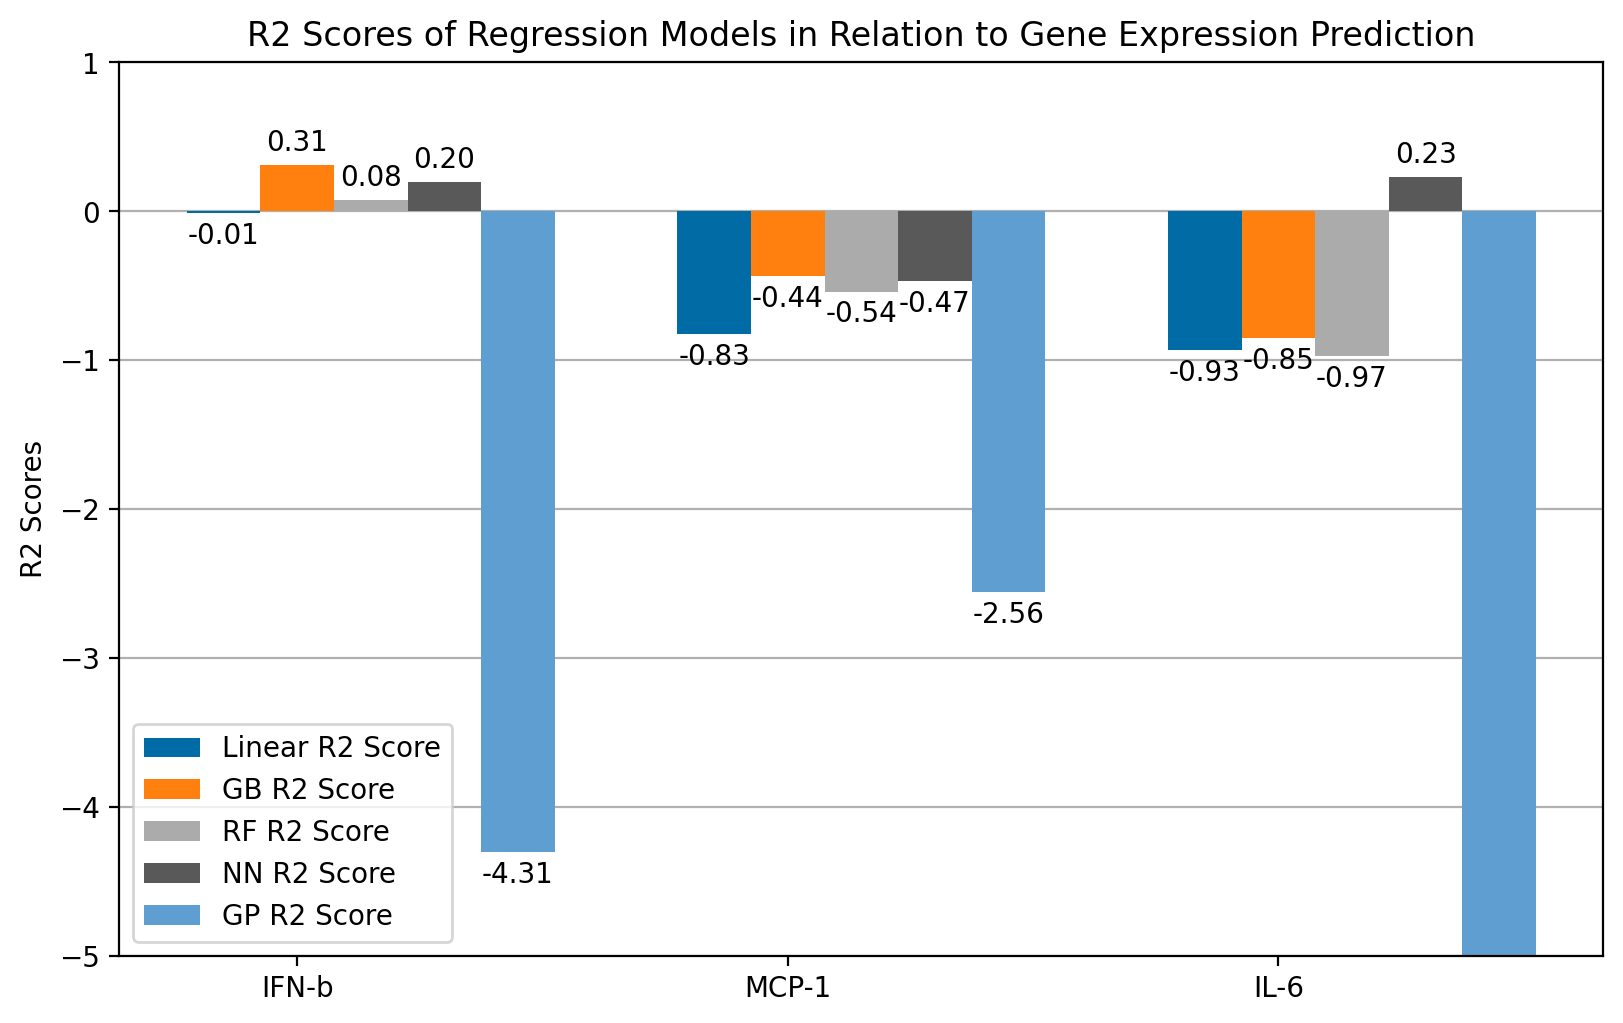

In [ ]:
cytokines = ["IFN-b", "MCP-1", "IL-6"]
r2_scores = {
    'Linear R2 Score': linear_r2,
    'GB R2 Score': gb_r2,
    'RF R2 Score': rf_r2,
    'NN R2 Score': nn_r2,
    'GP R2 Score': gp_r2
}

x = np.arange(len(cytokines))  # the label locations
width = 0.15  # the width of the bars
multiplier = 0

plt.style.use('tableau-colorblind10')

fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in r2_scores.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=3, fmt='%.2f')
    multiplier += 1

ax.set_ylabel('R2 Scores')
ax.set_title('R2 Scores of Regression Models in Relation to Gene Expression Prediction')
ax.set_xticks(x + width, cytokines)
ax.set_ylim(-5, 1)
ax.legend(r2_scores)

plt.grid(axis='y',) # enables gridlines
plt.gca().set_axisbelow(True) # places gridlines behind bars

plt.show()

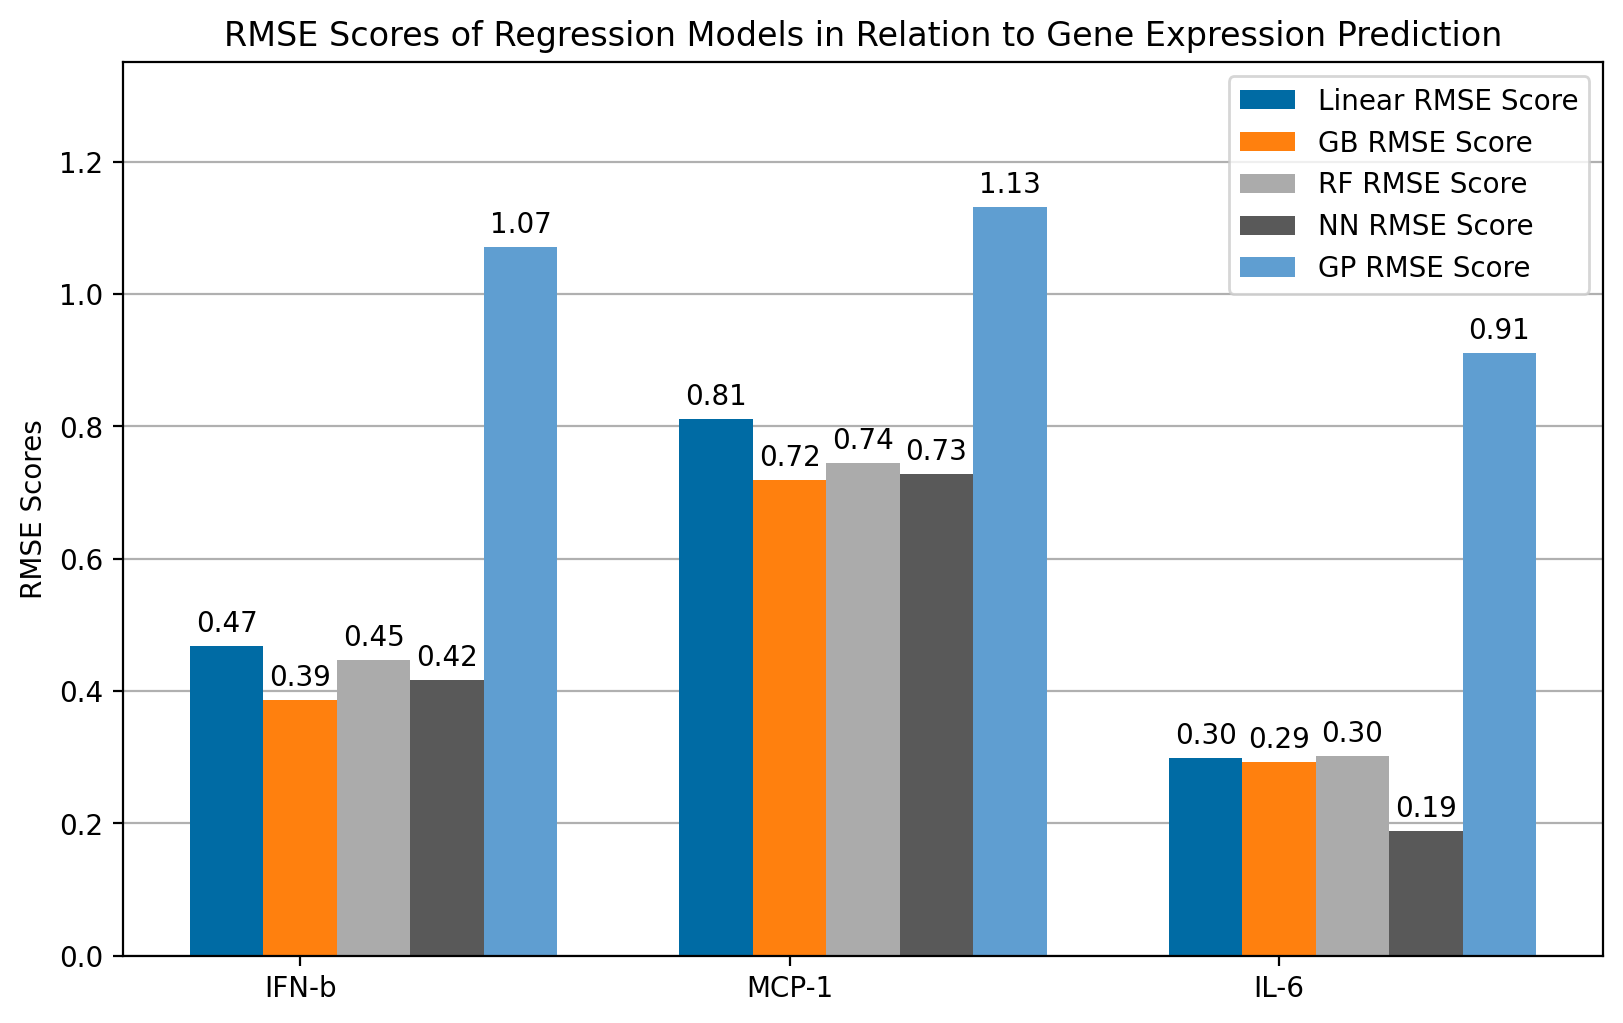

In [ ]:
cytokines = ["IFN-b", "MCP-1", "IL-6"]
rmse_scores = {
    'Linear RMSE Score': linear_rmse,
    'GB RMSE Score': gb_rmse,
    'RF RMSE Score': rf_rmse,
    'NN RMSE Score': nn_rmse,
    'GP RMSE Score': gp_rmse
}

x = np.arange(len(cytokines))  # the label locations
width = 0.15  # the width of the bars
multiplier = 0

plt.style.use('tableau-colorblind10')
fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in rmse_scores.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=3, fmt='%.2f')
    multiplier += 1

ax.set_ylabel('RMSE Scores')
ax.set_title('RMSE Scores of Regression Models in Relation to Gene Expression Prediction')
ax.set_xticks(x + width, cytokines)
ax.set_ylim(0, 1.35)
ax.legend(rmse_scores)

plt.grid(axis='y',) # enables gridlines
plt.gca().set_axisbelow(True) # places gridlines behind bars

colors = ['red', 'green', 'blue']

plt.show()

# Hyperparameter Tuning

## Gradient Boosting

In [ ]:
tuned_gb_r2 = []
tuned_gb_cv_r2 = []

### Gradient Boosting for IFN-b

In [ ]:
# parameters to test
param_grid = {
    'n_estimators': [2,4,8,16,32,100],
    'max_depth': [None,2,3,4],
    'min_samples_split': [None,1,2,3],
    'min_samples_leaf': [None,1,2],
    'learning_rate': [0.01, 0.05, 0.075, 0.1, 0.125],
    'max_features': [None,1,2,3,4,5]
}

# tests r2 score of all possible combinations of hyperparameters
# for GradientBoostingRegressor
grid = GridSearchCV(GradientBoostingRegressor(random_state=42),
                    param_grid,
                    scoring='r2',
                    refit=True,
                    verbose = 3, # prints info of each test
                    cv = 3) # number of cross-validations folds

# fits model to training data with best parameters
model_grid = grid.fit(i_fps_train, ifnb_train)

In [ ]:
print('Best hyperparameters are '+str(model_grid.best_params_))
print('Best score is: ' + str(model_grid.best_score_))
tuned_gb_cv_r2.append(model_grid.best_score_)

Best hyperparameters are {'learning_rate': 0.1, 'max_depth': None, 'max_features': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 16}
Best score is: -2.3040734829695966


In [ ]:
# predicts testing data based on g.b. model (no tuning)
gb.fit(i_fps_train, ifnb_train)
ifnb_pred = gb.predict(i_fps_test)
r2 = r2_score(ifnb_test, ifnb_pred) # r2 score
coeff, pval = stats.spearmanr(ifnb_test, ifnb_pred) # spearman rank correlation
print(r2)
print(coeff)

print('\n')

# predicts testing data based on g.b. model (w/ tuning)
ifnb_pred = model_grid.predict(i_fps_test)
r2 = r2_score(ifnb_test, ifnb_pred) # r2 score
coeff, pval = stats.spearmanr(ifnb_test, ifnb_pred) # spearman rank correlation
print(r2)
print(coeff)

tuned_gb_r2.append(r2)

0.3124448828269205
0.9999999999999999


-0.15859198667024788
-0.9999999999999999


### Gradient Boosting for MCP-1

In [ ]:
# parameters to test
param_grid = {
    'n_estimators': [1,2,4,8,16,100],
    'max_depth': [None,1,2,3],
    'min_samples_split': [None,1,2,3],
    'min_samples_leaf': [None,0,1,2],
    'learning_rate': [0.01, 0.1, 1, 2],
    'max_features': [None,1,2,3,4,5]
}

# tests r2 score of all possible combinations of hyperparameters
# for GradientBoostingRegressor
grid = GridSearchCV(GradientBoostingRegressor(random_state=42),
                    param_grid,
                    scoring='r2',
                    refit=True,
                    verbose = 3,
                    cv = 3)

# fits model to training data with best parameters
model_grid = grid.fit(m_fps_train, mcp1_train)

In [ ]:
print('Best hyperparameters are '+str(model_grid.best_params_))
print('Best score is: ' + str(model_grid.best_score_))
tuned_gb_cv_r2.append(model_grid.best_score_)

Best hyperparameters are {'learning_rate': 1, 'max_depth': 1, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 2}
Best score is: 0.3392333108018591


In [ ]:
# predicts testing data based on g.b. model (no tuning)
gb.fit(m_fps_train, mcp1_train)
mcp1_pred = gb.predict(m_fps_test)
r2 = r2_score(mcp1_test, mcp1_pred) # r2 score
coeff, pval = stats.spearmanr(mcp1_test, mcp1_pred) # spearman rank correlation
print(r2)
print(coeff)

print('\n')

# predicts testing data based on g.b. model (w/ tuning)
mcp1_pred = model_grid.predict(m_fps_test)
r2 = r2_score(mcp1_test, mcp1_pred) # r2 score
coeff, pval = stats.spearmanr(mcp1_test, mcp1_pred) # spearman rank correlation
print(r2)
print(coeff)

tuned_gb_r2.append(r2)

-0.4376056353991229
-0.9999999999999999


-3.178040123456789
0.9999999999999999


### Gradient Boosting for IL-6

In [ ]:
# parameters to test
param_grid = {
    'n_estimators': [4,8,16,32,100],
    'max_depth': [None, 1,2,3],
    'min_samples_split': [None,1,2,3],
    'min_samples_leaf': [None,1,2],
    'learning_rate': [0.01, 0.1, 0.125, 0.15],
    'max_features': [None, 1,2,3,4,5]
}

# tests r2 score of all possible combinations of hyperparameters
# for GradientBoostingRegressor
grid = GridSearchCV(GradientBoostingRegressor(random_state=42),
                    param_grid,
                    scoring='r2',
                    refit=True,
                    verbose = 3,
                    cv = 3)

# fits model to training data with best parameters
model_grid = grid.fit(il_fps_train, il_train)

In [ ]:
print('Best hyperparameters are '+str(model_grid.best_params_))
print('Best score is: ' + str(model_grid.best_score_))
tuned_gb_cv_r2.append(model_grid.best_score_)

Best hyperparameters are {'learning_rate': 0.125, 'max_depth': 1, 'max_features': 1, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 32}
Best score is: -0.7991592470821475


In [ ]:
# predicts testing data based on g.b. model (no tuning)
gb.fit(il_fps_train, il_train)
il_pred = gb.predict(il_fps_test)
r2 = r2_score(il_test, il_pred) # r2 score
coeff, pval = stats.spearmanr(il_test, il_pred) # spearman rank correlation
print(r2)
print(coeff)

print('\n')

# predicts testing data based on g.b. model (w/ tuning)
il_pred = model_grid.predict(il_fps_test)
r2 = r2_score(il_test, il_pred) # r2 score
coeff, pval = stats.spearmanr(il_test, il_pred) # spearman rank correlation
print(r2)
print(coeff)

tuned_gb_r2.append(r2)

-0.8544973174940365
0.9999999999999999


-0.9203923734034558
0.9999999999999999


## Random Forest

In [ ]:
tuned_rf_r2 = []
tuned_rf_cv_r2 = []

### Random Forest for IFN-b

In [ ]:
# parameters to test
param_grid = {
    'n_estimators': [2,4,8,16,100],
    'max_depth': [None,1,2,3],
    'min_samples_split': [None,1,2,3],
    'min_samples_leaf': [None,1,2],
    'max_features': [None,4,5,6]
}

# tests r2 score of all possible combinations of hyperparameters
# for RandomForestRegressor
grid = GridSearchCV(RandomForestRegressor(random_state=42),
                    param_grid,
                    scoring='r2',
                    refit=True,
                    verbose = 3,
                    cv = 3)

# fits model to training data with best parameters
model_grid = grid.fit(i_fps_train, ifnb_train)

In [ ]:
print('Best hyperparameters are '+str(model_grid.best_params_))
print('Best score is: ' + str(model_grid.best_score_))
tuned_rf_cv_r2.append(model_grid.best_score_)

Best hyperparameters are {'max_depth': None, 'max_features': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 4}
Best score is: -0.8227386292882101


In [ ]:
# predicts testing data based on r.f. model (no tuning)
rf.fit(i_fps_train, ifnb_train)
ifnb_pred = rf.predict(i_fps_test)
r2 = r2_score(ifnb_test, ifnb_pred) # r2 score
coeff, pval = stats.spearmanr(ifnb_test, ifnb_pred) # spearman rank correlation
print(r2)
print(coeff)

print('\n')

# predicts testing data based on r.f. model (w/ tuning)
ifnb_pred = model_grid.predict(i_fps_test)
r2 = r2_score(ifnb_test, ifnb_pred) # r2 score
coeff, pval = stats.spearmanr(ifnb_test, ifnb_pred) # spearman rank correlation
print(r2)
print(coeff)

tuned_rf_r2.append(r2)

0.07752579488958333
0.9999999999999999


0.5729419586079317
0.9999999999999999


### Random Forest for MCP-1

In [ ]:
# parameters to test
param_grid = {
    'n_estimators': [2,4,8,16,100],
    'max_depth': [None,1,2,3],
    'min_samples_split': [None,1,2,3],
    'min_samples_leaf': [None,1,2],
    'max_features': [None,4,5,6]
}

# tests r2 score of all possible combinations of hyperparameters
# for RandomForestRegressor
grid = GridSearchCV(RandomForestRegressor(random_state=42),
                    param_grid,
                    scoring='r2',
                    refit=True,
                    verbose = 3,
                    cv = 3)

# fits model to training data with best parameters
model_grid = grid.fit(m_fps_train, mcp1_train)

In [ ]:
print('Best hyperparameters are '+str(model_grid.best_params_))
print('Best score is: ' + str(model_grid.best_score_))
tuned_rf_cv_r2.append(model_grid.best_score_)

Best hyperparameters are {'max_depth': None, 'max_features': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 4}
Best score is: -1.7322605593168798


In [ ]:
# predicts testing data based on r.f. model (no tuning)
rf.fit(m_fps_train, mcp1_train)
mcp1_pred = rf.predict(m_fps_test)
r2 = r2_score(mcp1_test, mcp1_pred) # r2 score
coeff, pval = stats.spearmanr(mcp1_test, mcp1_pred) # spearman rank correlation
print(r2)
print(coeff)

print('\n')

# predicts testing data based on r.f. model (w/ tuning)
mcp1_pred = model_grid.predict(m_fps_test)
r2 = r2_score(mcp1_test, mcp1_pred) # r2 score
coeff, pval = stats.spearmanr(mcp1_test, mcp1_pred) # spearman rank correlation
print(r2)
print(coeff)

tuned_rf_r2.append(r2)

-0.540177805555556
-0.9999999999999999


-0.13820312499999998
0.9999999999999999


### Random Forest for IL-6

In [ ]:
# parameters to test
param_grid = {
    'n_estimators': [2,4,8,16,100],
    'max_depth': [None,1,2,3],
    'min_samples_split': [None,1,2,3],
    'min_samples_leaf': [None,1,2],
    'max_features': [None,4,5,6]
}

# tests r2 score of all possible combinations of hyperparameters
# for RandomForestRegressor
grid = GridSearchCV(RandomForestRegressor(random_state=42),
                    param_grid,
                    scoring='r2',
                    refit=True,
                    verbose = 3,
                    cv = 3)

# fits model to training data with best parameters
model_grid = grid.fit(il_fps_train, il_train)

In [ ]:
print('Best hyperparameters are '+str(model_grid.best_params_))
print('Best score is: ' + str(model_grid.best_score_))
tuned_rf_cv_r2.append(model_grid.best_score_)

Best hyperparameters are {'max_depth': 1, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 100}
Best score is: -6.8742590574849745


In [ ]:
# predicts testing data based on r.f. model (no tuning)
rf.fit(il_fps_train, il_train)
il_pred = rf.predict(il_fps_test)
r2 = r2_score(il_test, il_pred) # r2 score
coeff, pval = stats.spearmanr(il_test, il_pred) # spearman rank correlation
print(r2)
print(coeff)

print('\n')

# predicts testing data based on r.f. model (w/ tuning)
il_pred = model_grid.predict(il_fps_test)
r2 = r2_score(il_test, il_pred) # r2 score
coeff, pval = stats.spearmanr(il_test, il_pred) # spearman rank correlation
print(r2)
print(coeff)

tuned_rf_r2.append(r2)

-0.9721817198485618
0.9999999999999999


-0.6666596955110882
0.9999999999999999


### Neural Network for IFN-b

In [ ]:
tuned_nn_r2 = []
tuned_nn_cv_r2 = []

In [ ]:
# parameters to test
param_grid = {
    'hidden_layer_sizes': [(4,3)],
    'activation': ['identity','relu', 'tanh', 'logistic'],
    'solver': ['lbfgs','sgd','adam'],
    'learning_rate': ['constant','adaptive','invscaling'],
    'max_iter': [16, 32, 64, 128, 200, 256]
}

# tests r2 score of all possible combinations of hyperparameters
# for MLPRegressor
grid = GridSearchCV(MLPRegressor(random_state=42),
                    param_grid,
                    scoring='r2',
                    refit=True,
                    verbose = 3,
                    cv = 3)

# fits model to training data with best parameters
model_grid = grid.fit(i_fps_train, ifnb_train)

In [ ]:
print('Best hyperparameters are '+str(model_grid.best_params_))
print('Best score is: ' + str(model_grid.best_score_))
tuned_nn_cv_r2.append(model_grid.best_score_)

Best hyperparameters are {'activation': 'tanh', 'hidden_layer_sizes': (4, 3), 'learning_rate': 'adaptive', 'max_iter': 128, 'solver': 'sgd'}
Best score is: -1.6166273588066131


In [ ]:
# predicts testing data based on n.n. model (no tuning)
nn.fit(i_fps_train, ifnb_train)
ifnb_pred = nn.predict(i_fps_test)
r2 = r2_score(ifnb_test, ifnb_pred)
coeff, pval = stats.spearmanr(ifnb_test, ifnb_pred)
print(r2)
print(coeff)

print('\n')

# predicts testing data based on n.n. model (no tuning)
ifnb_pred = model_grid.predict(i_fps_test)
r2 = r2_score(ifnb_test, ifnb_pred)
coeff, pval = stats.spearmanr(ifnb_test, ifnb_pred)
print(r2)
print(coeff)

tuned_nn_r2.append(r2)

0.19583652957391917
0.9999999999999999


-0.06268016239502128
0.9999999999999999


### Neural Network for MCP-1

In [ ]:
# parameters to test
param_grid = {
    'hidden_layer_sizes': [(4,3)],
    'activation': ['identity','relu', 'tanh', 'logistic'],
    'solver': ['lbfgs','sgd','adam'],
    'learning_rate': ['constant','adaptive','invscaling'],
    'max_iter': [16, 32, 64, 128, 200]
}

# tests r2 score of all possible combinations of hyperparameters
# for MLPRegressor
grid = GridSearchCV(MLPRegressor(random_state=42),
                    param_grid,
                    scoring='r2',
                    refit=True,
                    verbose = 3,
                    cv = 3)

# fits model to training data with best parameters
model_grid = grid.fit(m_fps_train, mcp1_train)

In [ ]:
print('Best hyperparameters are '+str(model_grid.best_params_))
print('Best score is: ' + str(model_grid.best_score_))
tuned_nn_cv_r2.append(model_grid.best_score_)

Best hyperparameters are {'activation': 'logistic', 'hidden_layer_sizes': (4, 3), 'learning_rate': 'constant', 'max_iter': 32, 'solver': 'adam'}
Best score is: -0.8590669496571334


In [ ]:
# predicts testing data based on n.n. model (no tuning)
nn.fit(m_fps_train, mcp1_train)
mcp1_pred = nn.predict(m_fps_test)
r2 = r2_score(mcp1_test, mcp1_pred)
coeff, pval = stats.spearmanr(mcp1_test, mcp1_pred)
print(r2)
print(coeff)

print('\n')

# predicts testing data based on n.n. model (no tuning)
mcp1_pred = model_grid.predict(m_fps_test)
r2 = r2_score(mcp1_test, mcp1_pred)
coeff, pval = stats.spearmanr(mcp1_test, mcp1_pred)
print(r2)
print(coeff)

tuned_nn_r2.append(r2)

-0.4686257213065328
-0.9999999999999999


-1.7018638749118518
-0.9999999999999999


### Neural Network for IL-6

In [ ]:
# parameters to test
param_grid = {
    'hidden_layer_sizes': [(4,3)],
    'activation': ['identity','relu', 'tanh', 'logistic'],
    'solver': ['lbfgs','sgd','adam'],
    'learning_rate': ['constant','adaptive','invscaling'],
    'max_iter': [32, 64, 128, 200, 256]
}

# tests r2 score of all possible combinations of hyperparameters
# for MLPRegressor
grid = GridSearchCV(MLPRegressor(random_state=42),
                    param_grid,
                    scoring='r2',
                    refit=True,
                    verbose = 3,
                    cv = 3)

# fits model to training data with best parameters
model_grid = grid.fit(il_fps_train, il_train)

In [ ]:
print('Best hyperparameters are '+str(model_grid.best_params_))
print('Best score is: ' + str(model_grid.best_score_))
tuned_nn_cv_r2.append(model_grid.best_score_)

Best hyperparameters are {'activation': 'logistic', 'hidden_layer_sizes': (4, 3), 'learning_rate': 'constant', 'max_iter': 64, 'solver': 'lbfgs'}
Best score is: -3.0794406727710872


In [ ]:
# predicts testing data based on n.n. model (no tuning)
nn.fit(il_fps_train, il_train)
il_pred = nn.predict(il_fps_test)
r2 = r2_score(il_test, il_pred)
coeff, pval = stats.spearmanr(il_test, il_pred)
print(r2)
print(coeff)

print('\n')

# predicts testing data based on n.n. model (no tuning)
il_pred = model_grid.predict(il_fps_test)
r2 = r2_score(il_test, il_pred)
coeff, pval = stats.spearmanr(il_test, il_pred)
print(r2)
print(coeff)

tuned_nn_r2.append(r2)

0.2330465534322429
0.9999999999999999


0.7198585020180965
0.9999999999999999


### Gaussian Process for IFN-b

In [ ]:
tuned_gp_r2 = []
tuned_gp_cv_r2 = []

In [ ]:
# parameters to test
param_grid = {
    "kernel": [RBF(length_scale=l) for l in [1, 10, 100,150,200,400,800]],
    'alpha': [1e-10,1e-5,1e-4, 0.001,0.01,0.1,0.15,0.2,0.4,0.8],
    'normalize_y': [True, False],
    'n_restarts_optimizer': [0, 5, 10]
}

# tests r2 score of all possible combinations of hyperparameters
# for MLPRegressor
grid = GridSearchCV(GaussianProcessRegressor(random_state=42),
                    param_grid,
                    scoring='r2',
                    refit=True,
                    verbose = 3,
                    cv = 3)

# fits model to training data with best parameters
model_grid = grid.fit(i_fps_train, ifnb_train)

In [ ]:
print('Best hyperparameters are '+str(model_grid.best_params_))
print('Best score is: ' + str(model_grid.best_score_))
tuned_gp_cv_r2.append(model_grid.best_score_)

Best hyperparameters are {'alpha': 0.4, 'kernel': RBF(length_scale=200), 'n_restarts_optimizer': 0, 'normalize_y': True}
Best score is: -2.9195845972553616


In [ ]:
# predicts testing data based on g.b. model (no tuning)
gp.fit(i_fps_train, ifnb_train)
ifnb_pred = gp.predict(i_fps_test)
r2 = r2_score(ifnb_test, ifnb_pred)
coeff, pval = stats.spearmanr(ifnb_test, ifnb_pred)
print(r2)
print(coeff)

print('\n')

# predicts testing data based on g.b. model (no tuning)
ifnb_pred = model_grid.predict(i_fps_test)
r2 = r2_score(ifnb_test, ifnb_pred)
coeff, pval = stats.spearmanr(ifnb_test, ifnb_pred)
print(r2)
print(coeff)
tuned_gp_r2.append(r2)

-4.306740595808928
-0.9999999999999999


-0.08850091853907305
nan


C:\Users\t-9mbern\AppData\Local\anaconda3\envs\mbern25\lib\site-packages\scipy\stats\stats.py:4484: SpearmanRConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(SpearmanRConstantInputWarning())


### Gaussian Process for MCP-1

In [ ]:
# parameters to test
param_grid = {
    "kernel": [RBF(length_scale=l) for l in [1, 10, 100,150,200,400,800]],
    'alpha': [1e-10,1e-5,1e-4, 0.001,0.01,0.1,0.15,0.2,0.4,0.8],
    'normalize_y': [True, False],
    'n_restarts_optimizer': [0, 5, 10]
}

# tests r2 score of all possible combinations of hyperparameters
# for MLPRegressor
grid = GridSearchCV(GaussianProcessRegressor(random_state=42),
                    param_grid,
                    scoring='r2',
                    refit=True,
                    verbose = 3,
                    cv = 3)

# fits model to training data with best parameters
model_grid = grid.fit(m_fps_train, mcp1_train)

In [ ]:
print('Best hyperparameters are '+str(model_grid.best_params_))
print('Best score is: ' + str(model_grid.best_score_))
tuned_gp_cv_r2.append(model_grid.best_score_)

Best hyperparameters are {'alpha': 0.2, 'kernel': RBF(length_scale=10), 'n_restarts_optimizer': 0, 'normalize_y': False}
Best score is: -1.1691611768088894


In [ ]:
# predicts testing data based on g.b. model (no tuning)
gp.fit(m_fps_train, mcp1_train)
mcp1_pred = gp.predict(m_fps_test)
r2 = r2_score(mcp1_test, mcp1_pred)
coeff, pval = stats.spearmanr(mcp1_test, mcp1_pred)
print(r2)
print(coeff)

print('\n')

# predicts testing data based on g.b. model (no tuning)
mcp1_pred = model_grid.predict(m_fps_test)
r2 = r2_score(mcp1_test, mcp1_pred)
coeff, pval = stats.spearmanr(mcp1_test, mcp1_pred)
print(r2)
print(coeff)
tuned_gp_r2.append(r2)

-2.559999956874218
0.9999999999999999


-2.5599999999999996
0.9999999999999999


### Gaussian Process for IL-6

In [ ]:
# parameters to test
param_grid = {
    "kernel": [RBF(length_scale=l) for l in [1, 10, 100,150,200,400,800]],
    'alpha': [1e-10,1e-5,1e-4, 0.001,0.01,0.1,0.15,0.2,0.4,0.8],
    'normalize_y': [True, False],
    'n_restarts_optimizer': [0, 5, 10]
}

# tests r2 score of all possible combinations of hyperparameters
# for MLPRegressor
grid = GridSearchCV(GaussianProcessRegressor(random_state=42),
                    param_grid,
                    scoring='r2',
                    refit=True,
                    verbose = 3,
                    cv = 3)

# fits model to training data with best parameters
model_grid = grid.fit(il_fps_train, il_train)

In [ ]:
print('Best hyperparameters are '+str(model_grid.best_params_))
print('Best score is: ' + str(model_grid.best_score_))
tuned_gp_cv_r2.append(model_grid.best_score_)

Best hyperparameters are {'alpha': 0.4, 'kernel': RBF(length_scale=10), 'n_restarts_optimizer': 0, 'normalize_y': True}
Best score is: -8.73621917542532


In [ ]:
# predicts testing data based on g.p. model (no tuning)
gp.fit(il_fps_train, il_train)
il_pred = gp.predict(il_fps_test)
r2 = r2_score(il_test, il_pred)
coeff, pval = stats.spearmanr(il_test, il_pred)
print(r2)
print(coeff)

print('\n')

# predicts testing data based on g.p. model (no tuning)
il_pred = model_grid.predict(il_fps_test)
r2 = r2_score(il_test, il_pred)
coeff, pval = stats.spearmanr(il_test, il_pred)
print(r2)
print(coeff)
tuned_gp_r2.append(r2)

-16.94375243097526
0.9999999999999999


-1.1295483770180375
0.9999999999999999


In [ ]:
r2_scores = {
    'Gradient Boosting': gb_r2,
    'Random Forest': rf_r2,
    'Neural Network': nn_r2,
    'Gaussian Process': gp_r2,
}

tuned_r2_scores = {
    'Tuned GB R2 Score': tuned_gb_r2,
    'Tuned RF R2 Score': tuned_rf_r2,
    'Tuned NN R2 Score': tuned_nn_r2,
    'Tuned GP R2 Score': tuned_gp_r2
}

tuned_r2_cv_scores = {
    'Tuned GB CV R2 Score': tuned_gb_cv_r2,
    'Tuned RF CV R2 Score': tuned_rf_cv_r2,
    'Tuned NN CV R2 Score': tuned_nn_cv_r2,
    'Tuned GP CV R2 Score': tuned_gp_cv_r2
}

In [ ]:
r2_scores

{'GB R2 Score': [0.3124448828269205, -0.4376056353991229, -0.8544973174940365],
 'RF R2 Score': [0.07752579488958333, -0.540177805555556, -0.9721817198485618],
 'NN R2 Score': [0.19583652957391917, -0.4686257213065328, 0.2330465534322429],
 'GP R2 Score': [-4.306740595808928, -2.559999956874218, -16.94375243097526]}

In [ ]:
tuned_r2_scores

{'Tuned GB R2 Score': [-0.15859198667024788,
  -3.178040123456789,
  -0.9203923734034558],
 'Tuned RF R2 Score': [0.5729419586079317,
  -0.13820312499999998,
  -0.6666596955110882],
 'Tuned NN R2 Score': [-0.06268016239502128,
  -1.7018638749118518,
  0.7198585020180965],
 'Tuned GP R2 Score': [-0.08850091853907305,
  -2.5599999999999996,
  -1.1295483770180375]}

In [ ]:
tuned_r2_cv_scores

{'Tuned GB CV R2 Score': [-2.3040734829695966,
  0.3392333108018591,
  -0.7991592470821475],
 'Tuned RF CV R2 Score': [-0.8227386292882101,
  -1.7322605593168798,
  -6.8742590574849745],
 'Tuned NN CV R2 Score': [-1.6166273588066131,
  -0.8590669496571334,
  -3.0794406727710872],
 'Tuned GP CV R2 Score': [-2.9195845972553616,
  -1.1691611768088894,
  -8.73621917542532]}

##  Graphs (post tuning)

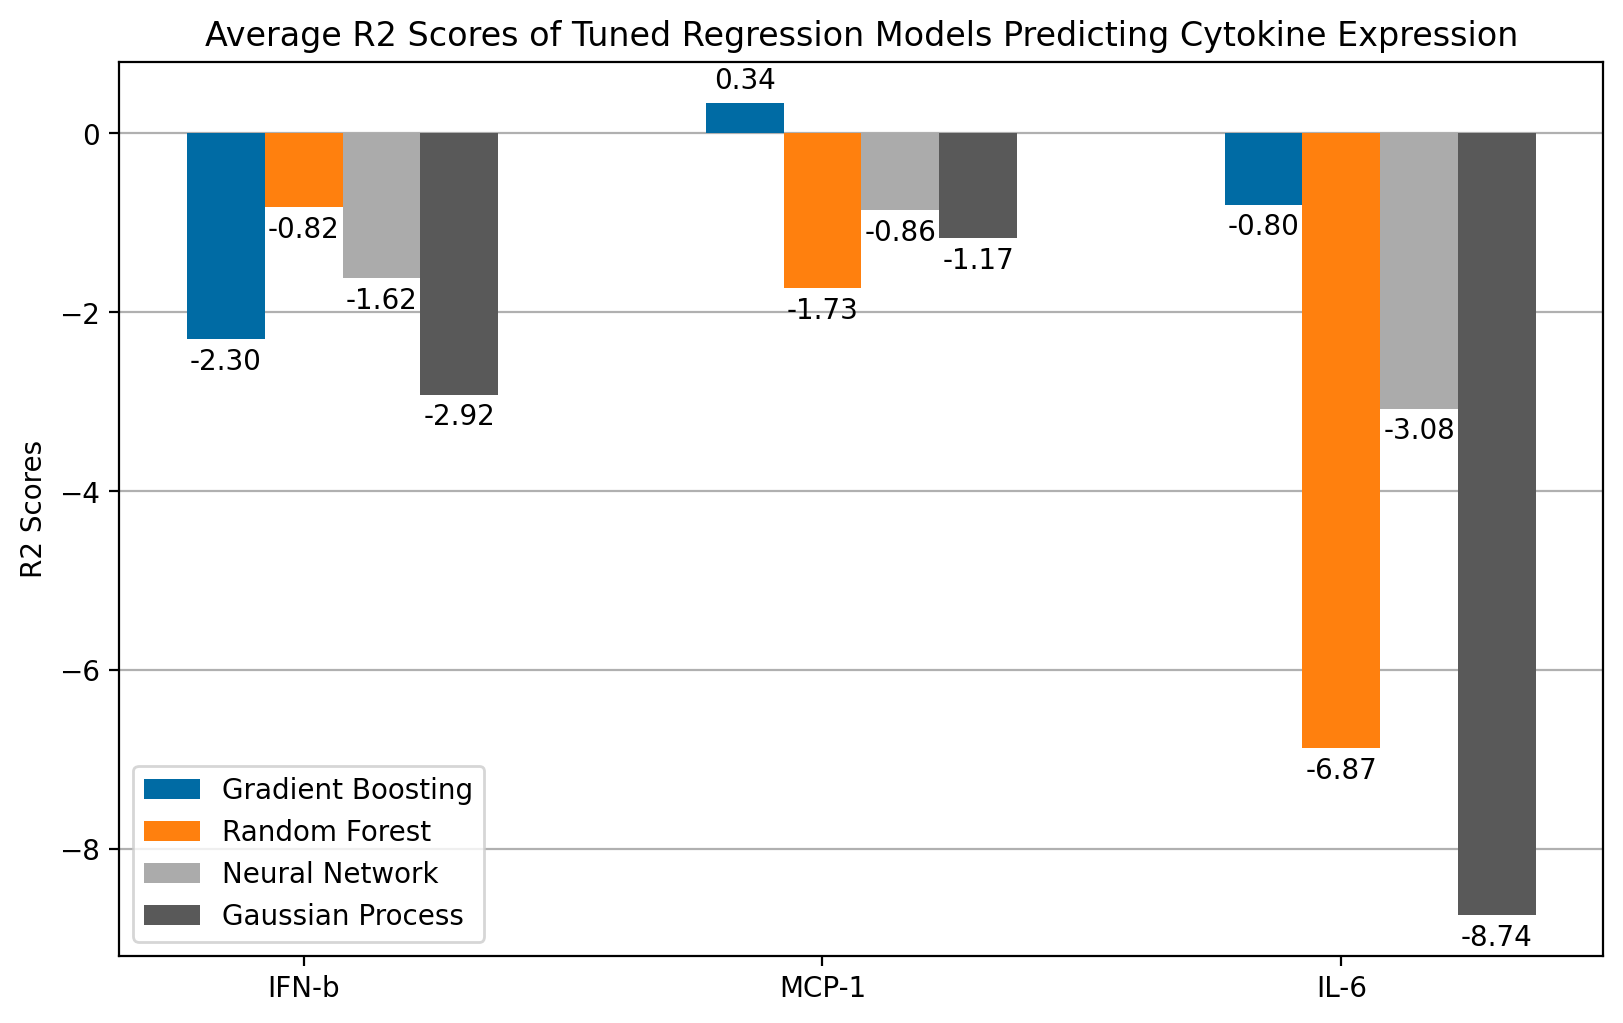

In [ ]:
cytokines = ["IFN-b", "MCP-1", "IL-6"]

x = np.arange(len(cytokines))  # the label locations
width = 0.15  # the width of the bars
multiplier = 0

plt.style.use('tableau-colorblind10')
fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in tuned_r2_cv_scores.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=3, fmt='%.2f')
    multiplier += 1

ax.set_ylabel('R2 Scores')
ax.set_title('Average R2 Scores of Tuned Regression Models Predicting Cytokine Expression')
ax.set_xticks(x + width, cytokines)
ax.legend(r2_scores)

plt.grid(axis='y',) # enables gridlines
plt.gca().set_axisbelow(True) # places gridlines behind bars

plt.show()

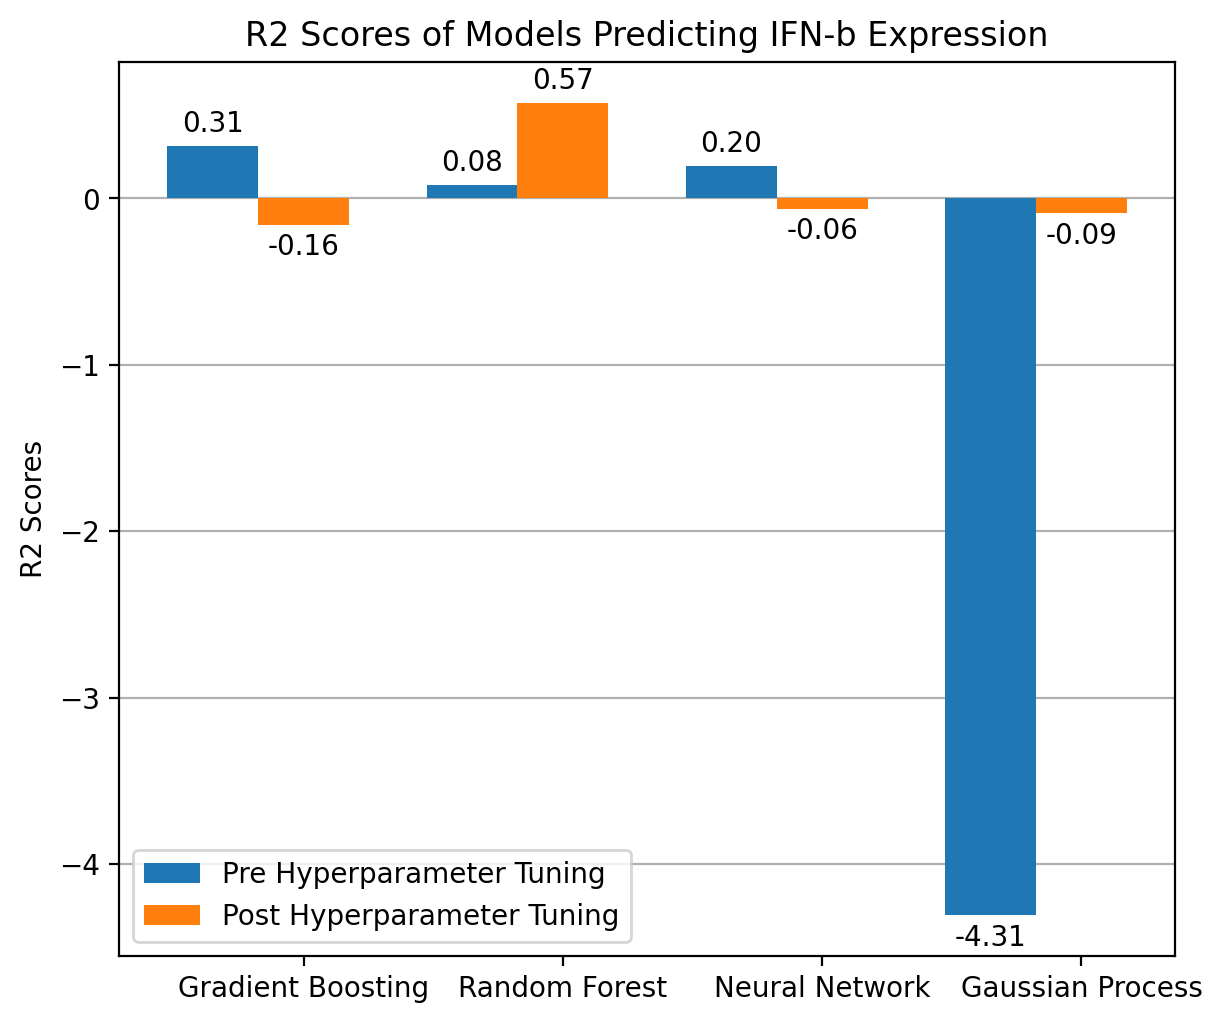

In [ ]:
models = ["Gradient Boosting", "Random Forest", "Neural Network", "Gaussian Process"]

ifnb_r2 = {
    'Pre Hyperparameter Tuning': [
        r2_scores['GB R2 Score'][0],
        r2_scores['RF R2 Score'][0],
        r2_scores['NN R2 Score'][0],
        r2_scores['GP R2 Score'][0]
    ],

    'Post Hyperparameter Tuning': [
        tuned_r2_scores['Tuned GB R2 Score'][0],
        tuned_r2_scores['Tuned RF R2 Score'][0],
        tuned_r2_scores['Tuned NN R2 Score'][0],
        tuned_r2_scores['Tuned GP R2 Score'][0]
    ]
}

x = np.arange(len(models))  # the label locations
width = 0.35  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(figsize=(6, 5),layout='constrained')

for attribute, measurement in ifnb_r2.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=3, fmt='%.2f')
    multiplier += 1

ax.set_ylabel('R2 Scores')
ax.set_title('R2 Scores of Models Predicting IFN-b Expression')
ax.set_xticks(x + width, models)
ax.legend(ifnb_r2)

plt.grid(axis='y',) # enables gridlines
plt.gca().set_axisbelow(True) # places gridlines behind bars

plt.show()

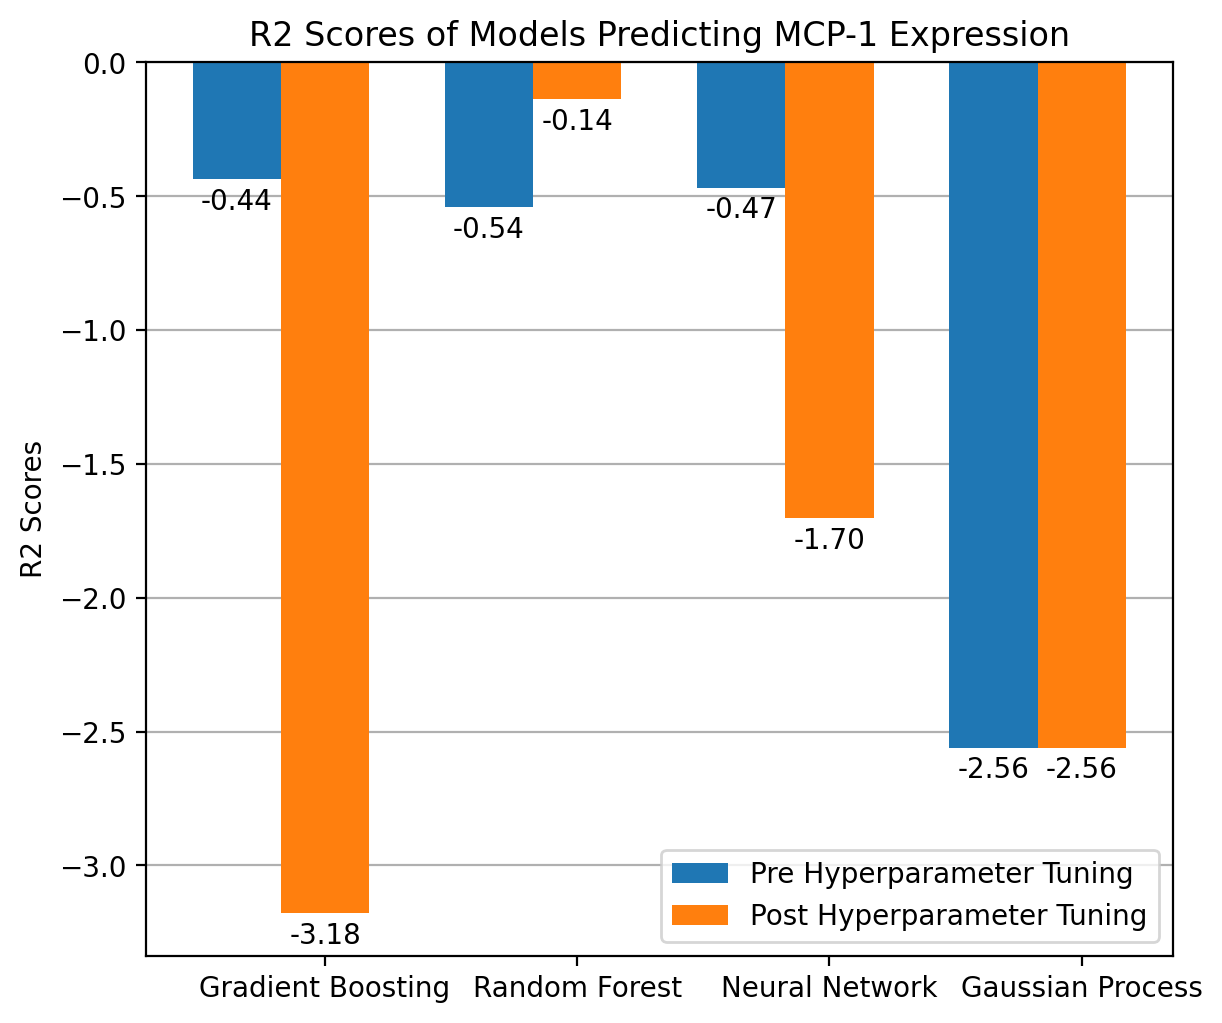

In [ ]:
models = ["Gradient Boosting", "Random Forest", "Neural Network", "Gaussian Process"]

ifnb_r2 = {
    'Pre Hyperparameter Tuning': [
        r2_scores['GB R2 Score'][1],
        r2_scores['RF R2 Score'][1],
        r2_scores['NN R2 Score'][1],
        r2_scores['GP R2 Score'][1]
    ],

    'Post Hyperparameter Tuning': [
        tuned_r2_scores['Tuned GB R2 Score'][1],
        tuned_r2_scores['Tuned RF R2 Score'][1],
        tuned_r2_scores['Tuned NN R2 Score'][1],
        tuned_r2_scores['Tuned GP R2 Score'][1]
    ]
}

x = np.arange(len(models))  # the label locations
width = 0.35  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(figsize=(6, 5),layout='constrained')

for attribute, measurement in ifnb_r2.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=3, fmt='%.2f')
    multiplier += 1

ax.set_ylabel('R2 Scores')
ax.set_title('R2 Scores of Models Predicting MCP-1 Expression')
ax.set_xticks(x + width, models)
ax.legend(ifnb_r2)

plt.grid(axis='y',) # enables gridlines
plt.gca().set_axisbelow(True) # places gridlines behind bars

plt.show()

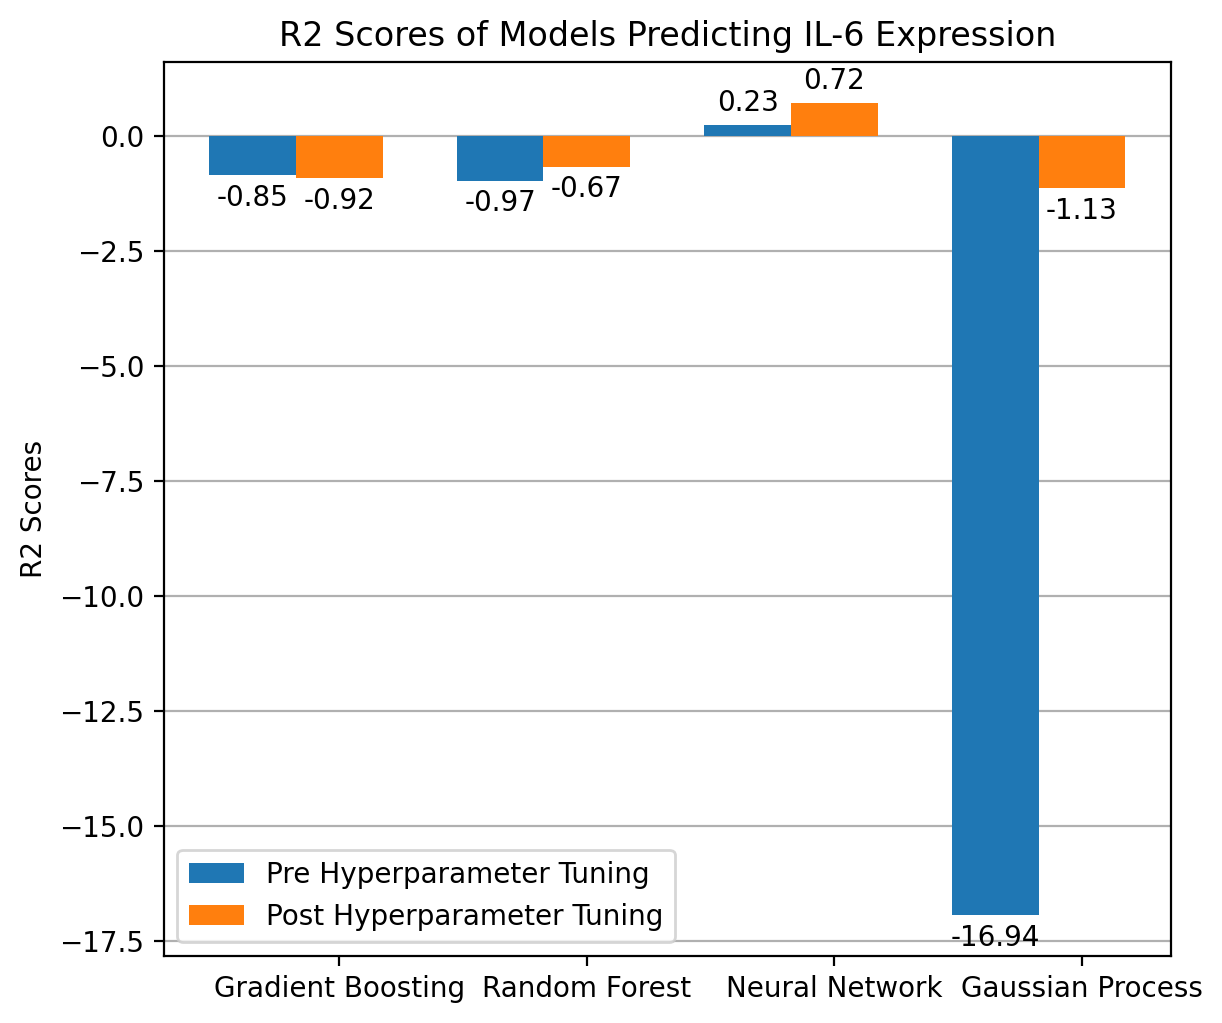

In [ ]:
models = ["Gradient Boosting", "Random Forest", "Neural Network", "Gaussian Process"]

ifnb_r2 = {
    'Pre Hyperparameter Tuning': [
        r2_scores['GB R2 Score'][2],
        r2_scores['RF R2 Score'][2],
        r2_scores['NN R2 Score'][2],
        r2_scores['GP R2 Score'][2]
    ],

    'Post Hyperparameter Tuning': [
        tuned_r2_scores['Tuned GB R2 Score'][2],
        tuned_r2_scores['Tuned RF R2 Score'][2],
        tuned_r2_scores['Tuned NN R2 Score'][2],
        tuned_r2_scores['Tuned GP R2 Score'][2]
    ]
}

x = np.arange(len(models))  # the label locations
width = 0.35  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(figsize=(6, 5),layout='constrained')

for attribute, measurement in ifnb_r2.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=3, fmt='%.2f')
    multiplier += 1

ax.set_ylabel('R2 Scores')
ax.set_title('R2 Scores of Models Predicting IL-6 Expression')
ax.set_xticks(x + width, models)
ax.legend(ifnb_r2, loc='lower left')

plt.grid(axis='y',) # enables gridlines
plt.gca().set_axisbelow(True) # places gridlines behind bars

plt.show()